# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, find_hrs_files,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
     # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,

    
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [14]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field):
#   HRPILOT-14-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-14-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-15-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-15-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "HR16_POST_HOC_SINGLE_FIXED" # HR16__CONFIGB_POST_HOC_SINGLE_FIXED # HR16_POST_HOC_FIXED # HR16_POST_HOC_SINGLE_FIXED

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found — HRS2 sections will be skipped")


Recording directory: HR16_POST_HOC_SINGLE_FIXED
  HRS1 file: HR16_POST_HOC_SINGLE_FIXED_20260501T141402.hrs1
  HRS2 file: HR16_POST_HOC_SINGLE_FIXED_20260501T152159.hrs2


In [15]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               HR16_POST_HOC_SINGLE_FIXED_20260501T141402.hrs1
  File version:       0
  Subject ID:         HR16_POST_HOC_SINGLE_FIXED
  Session datetime:   2026-05-01 14:14:02.418116
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=296.91 µV, elapsed=0.002 h, 20 window sizes

  Trials found:       2
  EMG data blocks:    224

=== First Trial ===
  End datetime:       2026-05-01 14:14:06.827536
  Start index:        57551
  Grand mean:         298.9945
  Bins count:         47
  Monitored signal N: 11750

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1']
  Raw channels:       3 x 192 samples
  Diff samples:       192
  Filtered samples:   192
  Abs samples:        192


# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [16]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               HR16_POST_HOC_SINGLE_FIXED_20260501T152159.hrs2
  File version:       3  (v3: + unipolar_trial_data)
  Subject ID:         HR16_POST_HOC_SINGLE_FIXED
  Session start time: 2026-05-01 15:21:59.326419
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       600
  EMG data blocks:    49192

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1']
  Raw channels:   3 x 191 samples
  Diff samples:   191


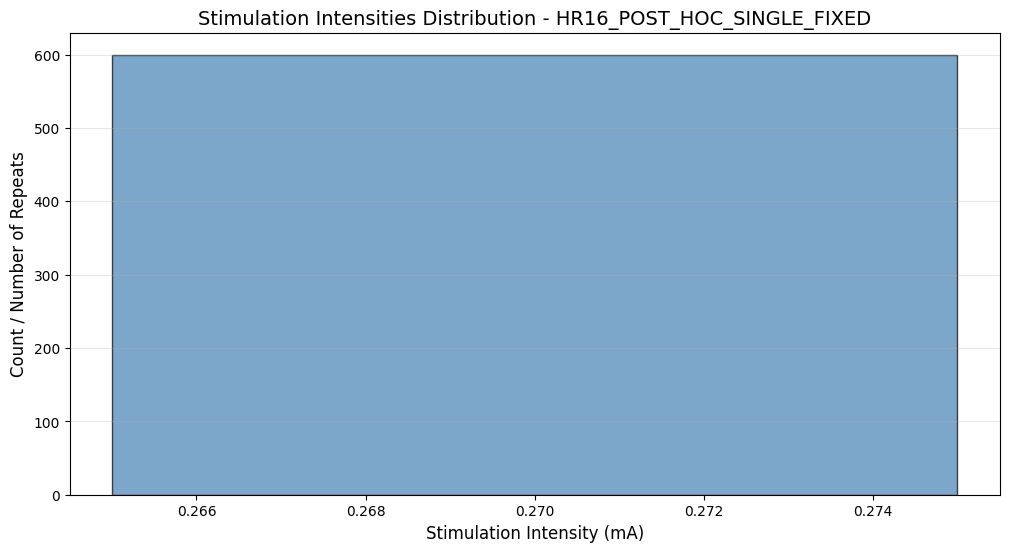

In [17]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# Section 3b: "Most Recent Background" + "Background EMG Level"

Recreates the H-Reflex App recruitment-curve trial-plot widgets from `MhRecruitmentCurveStage.get_trial_plot_options`:

- **Most recent background** — bar chart of the pre-stim |EMG| bins.
- **EMG Level** — scatter of background grand means across trials.

Bins are reconstructed from `hrs2_emg_blocks` over a fixed monitoring window (default 2500 ms ending at trigger time).

In [ ]:
# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500)

Reconstructed background bins for 600/600 trials (window=2500 ms).


# Section 6: HRS2 Detailed Analysis

Interactive averaged-waveform paged grid (with M/H peak markers and signal overlays) plus the normalized and raw recruitment curves. The cell below sets the analysis parameters; the cell after that calls `plot_hrs2_analysis`.

In [21]:
#  Configuration 
PRE_PLOT_MS  = 2   # ms before stim onset to display
POST_PLOT_MS = 15  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
M_WAVE_START_MS = 3.5
M_WAVE_END_MS= 5.5
H_WAVE_START_MS = 6.5
H_WAVE_END_MS   = 12

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


Loaded 1 amplitude groups across 1 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


c:\Users\yahri\AppData\Roaming\Lib\site-packages\scipy\interpolate\_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


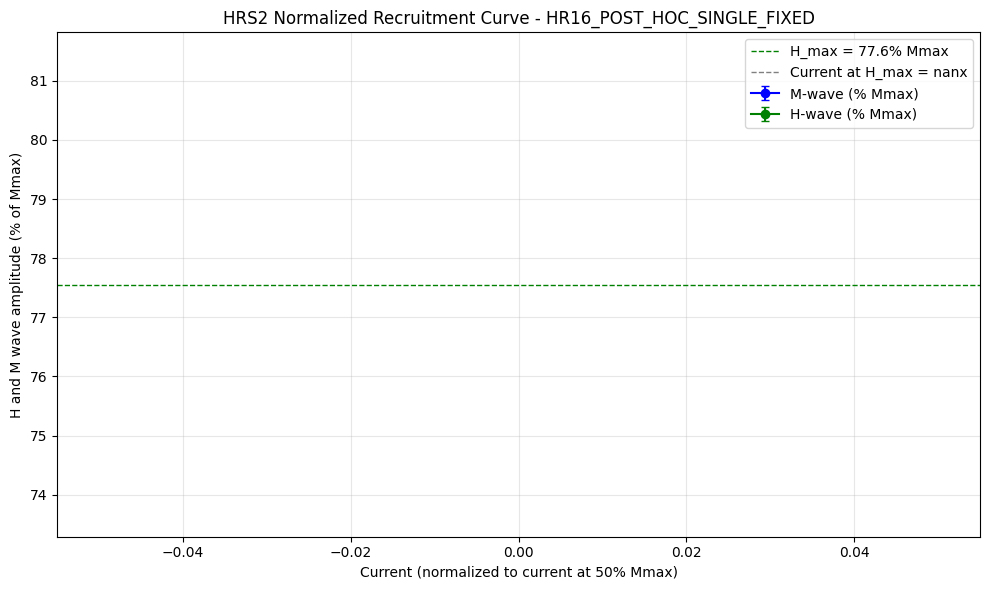

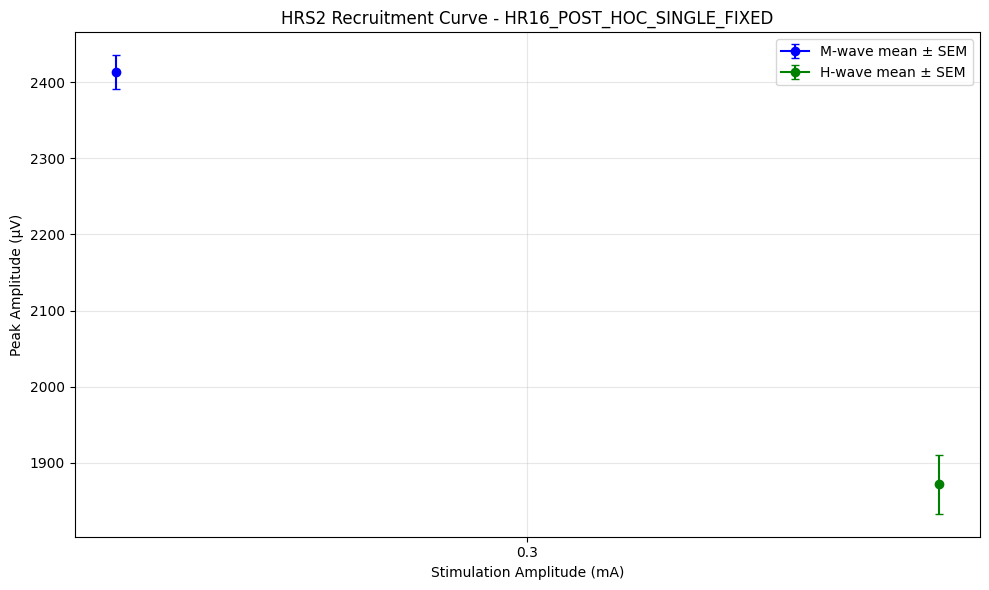

M_max = 2413.58 µV
H_max = 1871.85 µV (77.6% of M_max)
Current at 50% M_max = nan mA
Current at H_max = 0.27 mA (nanx normalized)


In [ ]:
# ---- HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ----
plot_hrs2_analysis(
    hrs2_trials, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)